In [2]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.1 MB 7.6 MB/s eta 0:00:01
   ---------------- ----------------------- 2.9/7.1 MB 8.0 MB/s eta 0:00:01
   ----------------------- -------

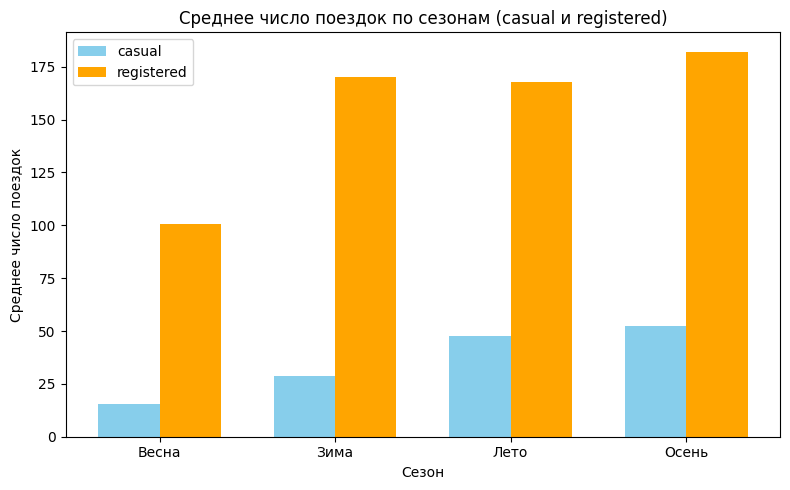

In [6]:
import matplotlib.pyplot as plt
import numpy as np

season_names = {1: 'Весна', 2: 'Лето', 3: 'Осень', 4: 'Зима'}
df['season_name'] = df['season'].map(season_names)

seasonal_avg = df.groupby('season_name')[['casual', 'registered']].mean().reset_index()

x = np.arange(len(seasonal_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, seasonal_avg['casual'], width, label='casual', color='skyblue')
bars2 = ax.bar(x + width/2, seasonal_avg['registered'], width, label='registered', color='orange')

ax.set_xlabel('Сезон')
ax.set_ylabel('Среднее число поездок')
ax.set_title('Среднее число поездок по сезонам (casual и registered)')
ax.set_xticks(x)
ax.set_xticklabels(seasonal_avg['season_name'])
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
high_traffic = df[df['count'] > 500]
num_high = len(high_traffic)
season_counts = high_traffic['season_name'].value_counts()

print(f"Результат задачи 3: Количество наблюдений с count > 500: {num_high}")
print("Распределение по сезонам:")
print(season_counts)
most_freq_season = season_counts.idxmax()
print(f"Чаще всего такие наблюдения встречаются в сезоне: {most_freq_season} ({season_counts.max()} раз)")

Результат задачи 3: Количество наблюдений с count > 500: 797
Распределение по сезонам:
season_name
Лето     281
Осень    271
Зима     186
Весна     59
Name: count, dtype: int64
Чаще всего такие наблюдения встречаются в сезоне: Лето (281 раз)


In [8]:
import pandas as pd

# Загрузка данных
df = pd.read_csv("5_train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# Извлечение месяца
df["month"] = df["datetime"].dt.month

# Группировка по месяцам: средняя температура и среднее число поездок
monthly_stats = df.groupby("month").agg({
    "temp": "mean",
    "count": "mean"
}).round(2)

# Переименование индексов в русские названия месяцев
month_names = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр", 5: "Май", 6: "Июн",
    7: "Июл", 8: "Авг", 9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}
monthly_stats.index = [month_names[m] for m in monthly_stats.index]

# Вывод на экран
print(monthly_stats)

# Сохранение в CSV (с разделителем ; и кодировкой UTF-8)
monthly_stats.to_csv("monthly_temp_rides.csv", sep=";", encoding="utf-8-sig")
print("\nФайл сохранён: monthly_temp_rides.csv")

      temp   count
Янв   9.84   90.37
Фев  11.80  110.00
Мар  15.90  148.17
Апр  18.72  184.16
Май  22.67  219.46
Июн  27.06  242.03
Июл  30.84  235.33
Авг  29.74  234.12
Сен  25.78  233.81
Окт  20.93  227.70
Ноя  15.19  193.68
Дек  13.83  175.61

Файл сохранён: monthly_temp_rides.csv
